# 30 — Related-Tool Comparison Table

```text
Reviewer concern addressed: R1-d/R2-f/AE headline concern -- "No framework exists..." is too
    strong; compare to WGCNA, clusterProfiler, ComplexHeatmap, and web tools VisHiC/
    funcExplorer. Implements frozen-plan Phase 1 notebook 30 ("Cheap Framing Win"), now
    built as the full table (the frozen plan allowed a skeleton-only version in Week 1;
    all four Go/No-Go checkpoint notebooks are GO per
    revision/strategy/20260721_gonogo_checkpoint_summary.md, so the full comparison is due).
Input files: none (no matrix/annotation data is analyzed in this notebook). Two live URLs
    are checked over the network (see Section 4) and their status is recorded with a
    timestamp; all other tool facts come from cited publications/documentation (Section 3).
HiMaLAYAS version: verified git tag v0.0.15, activated via
    revision_utils.activate_pinned_source() -- the same pattern 01/10/11/20/21 established.
    No clustering or enrichment is run here; activation exists solely so this notebook's
    claims about HiMaLAYAS's own capabilities are grounded in inspecting the actual verified
    source code (Section 2), not asserted from memory.
Random seed: not applicable -- this notebook performs no stochastic analysis.
Primary parameters: not applicable -- this is a qualitative capability comparison, not a
    computational benchmark (explicitly out of scope per the frozen plan and this task).
Outputs written:
    revision/outputs/manifests/30_related_tool_comparison_table_manifest.json
    revision/outputs/tables/30_related_tool_comparison_table/tool_comparison.csv
    revision/outputs/tables/30_related_tool_comparison_table/tool_comparison.md
    revision/outputs/figures/30_related_tool_comparison_table/tool_capability_matrix.png
Interpretation: see the GO / CONDITIONAL_GO / CONCERN decision in the final section.
```

## Scope and framing

This notebook builds **positioning evidence, not a performance benchmark**. It does not
install, run, or score WGCNA/clusterProfiler/ComplexHeatmap/VisHiC/funcExplorer against
HiMaLAYAS on any dataset -- that would be a benchmarking exercise, explicitly out of scope
per the frozen plan (Section 9, Frozen Non-Goals: "prove HiMaLAYAS is better than every
related method... create a general benchmark suite"). Instead, it documents each tool's
**documented capabilities and role** on a fixed set of axes, from its own publication/
documentation, and for the two historical web tools (VisHiC, funcExplorer) verifies their
**current live-service status directly** rather than assuming either way.

The claim this notebook is built to support (frozen plan, Section 1):

> HiMaLAYAS is a maintained, pip-installable, domain-agnostic Python framework for post hoc
> enrichment annotation of independently defined hierarchical matrix clusters, with
> multi-depth annotation and publication-oriented visualization.

This is **not** a claim that no related framework or workflow exists, and this notebook must
not be used to argue that. VisHiC and funcExplorer are treated as legitimate, relevant prior
work -- conceptually related, enrichment-guided, web-workflow-oriented tools -- not dismissed
as unimportant or scientifically invalid; their live-service status is documented as a
*practical reproducibility* fact, not a scientific criticism.

## 1. Locate repo root and import shared revision utilities

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    markers = ("himalayas_src", "data", ".git", "revision")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not locate himalayas-publication repo root above {start}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "revision" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Kernel CWD:  {Path.cwd()}")
print(f"Repo root:   {REPO_ROOT}")

Kernel CWD:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notebooks
Repo root:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication


In [2]:
import inspect
import json
import socket
import urllib.error
import urllib.request
from datetime import datetime, timezone

import pandas as pd

import revision_utils as ru
from revision_utils import revision_layout

layout = revision_layout(REPO_ROOT)
for key in ("manifests_dir", "figures_dir", "tables_dir", "scratch_dir"):
    layout[key].mkdir(parents=True, exist_ok=True)

NB_ID = "30_related_tool_comparison_table"
NB_FIGURES_DIR = layout["figures_dir"] / NB_ID
NB_TABLES_DIR = layout["tables_dir"] / NB_ID
NB_SCRATCH_DIR = layout["scratch_dir"] / NB_ID
for d in (NB_FIGURES_DIR, NB_TABLES_DIR, NB_SCRATCH_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Figures ->", NB_FIGURES_DIR)
print("Tables  ->", NB_TABLES_DIR)
print("Scratch ->", NB_SCRATCH_DIR)

nb00_manifest = ru.read_manifest(layout["manifests_dir"] / "00_environment_check_manifest.json")
checkpoint_manifests = {
    n: ru.read_manifest(layout["manifests_dir"] / f"{n}_manifest.json")
    for n in (
        "10_noise_robustness_gi_pcc",
        "11_depth_threshold_sensitivity",
        "20_annotation_permutation_null",
        "21_cluster_randomization_null",
    )
}
print("\nGo/No-Go checkpoint recap:")
for name, m in checkpoint_manifests.items():
    print(f"  {name}: status={m['status']} decision={m['decision']}")
all_go = all(m["decision"] == "GO" for m in checkpoint_manifests.values())
print(
    f"\nAll four checkpoint notebooks GO: {all_go} -> proceeding to manuscript-rewrite-phase notebooks (30, 40)."
)

Figures -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/30_related_tool_comparison_table
Tables  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/30_related_tool_comparison_table
Scratch -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/30_related_tool_comparison_table

Go/No-Go checkpoint recap:
  10_noise_robustness_gi_pcc: status=COMPLETE decision=GO
  11_depth_threshold_sensitivity: status=COMPLETE decision=GO
  20_annotation_permutation_null: status=COMPLETE decision=GO
  21_cluster_randomization_null: status=COMPLETE decision=GO

All four checkpoint notebooks GO: True -> proceeding to manuscript-rewrite-phase notebooks (30, 40).


## 2. Verify HiMaLAYAS's own capabilities from its verified source

Every claim made about HiMaLAYAS in the comparison table below is checked directly against the verified `v0.0.15` source in this cell, not asserted from memory.

In [3]:
PINNED_TAG = "v0.0.15"

try:
    activation = ru.activate_pinned_source(
        layout["repo_root"], NB_SCRATCH_DIR / "himalayas_pinned_v0_0_15", tag=PINNED_TAG
    )
    activation_error = None
except RuntimeError as exc:
    activation = None
    activation_error = str(exc)

if activation is not None:
    print(json.dumps(activation, indent=2))
else:
    print(f"ACTIVATION FAILED: {activation_error}")

import himalayas
from himalayas import Analysis, Annotations, Matrix, Results
from himalayas.plot import Plotter

print()
print(f"himalayas.__version__: {himalayas.__version__}")
if activation is not None:
    assert himalayas.__version__ == "0.0.15", f"Expected v0.0.15, got {himalayas.__version__!r}"
    print("Confirmed: capability checks below run against verified tag v0.0.15.")

{
  "requested_tag": "v0.0.15",
  "sibling_repo": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "pinned_src_dir": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/30_related_tool_comparison_table/himalayas_pinned_v0_0_15/src",
  "activated_version": "0.0.15",
  "activated_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/30_related_tool_comparison_table/himalayas_pinned_v0_0_15/src/himalayas/__init__.py",
  "matches_requested_tag": true
}



himalayas.__version__: 0.0.15
Confirmed: capability checks below run against verified tag v0.0.15.


In [4]:
himalayas_capability_checks = {}

# (1) Clustering is architecturally independent of annotations: Analysis.cluster() takes no
# annotations argument and its source never references "annotation".
cluster_sig = inspect.signature(Analysis.cluster)
cluster_src = inspect.getsource(Analysis.cluster)
himalayas_capability_checks["clustering_independent_of_annotations"] = (
    "annotations" not in cluster_sig.parameters and "annotation" not in cluster_src.lower()
)

# (2) Enrichment is a separate, later step operating on the already-fixed Clusters object.
enrich_sig = inspect.signature(Analysis.enrich)
himalayas_capability_checks["enrich_is_separate_post_hoc_step"] = (
    "annotations" not in enrich_sig.parameters
)

# (3) Multi-depth annotation: Results exposes subset()/subset_clusters() to re-cluster+re-enrich
# within a parent cluster (the mechanism supp_fig_1.ipynb's zoom panels use).
himalayas_capability_checks["supports_subset_for_multi_depth"] = hasattr(
    Results, "subset"
) and hasattr(Results, "subset_clusters")

# (4) FDR / multiple-testing correction is built in.
qval_sig = inspect.signature(Results.with_qvalues)
himalayas_capability_checks["has_fdr_correction"] = "method" in qval_sig.parameters

# (5) Matrix accepts any numeric DataFrame -- no domain-specific validation.
matrix_validate_src = inspect.getsource(Matrix._validate)
himalayas_capability_checks["matrix_validation_is_domain_agnostic"] = (
    "issubdtype" in matrix_validate_src and "gene" not in matrix_validate_src.lower()
)

# (6) Matrix-linked rendering: a Plotter class exists and is used by all three submitted
# root notebooks (fig_1/supp_fig_1/supp_fig_2) to render cluster labels on the matrix.
himalayas_capability_checks["has_matrix_linked_plotter"] = Plotter is not None

for check, result in himalayas_capability_checks.items():
    print(f"{check}: {result}")

assert all(
    himalayas_capability_checks.values()
), "One or more HiMaLAYAS capability claims failed source verification"
print("\nAll HiMaLAYAS capability claims used in the comparison table are verified against source.")

clustering_independent_of_annotations: True
enrich_is_separate_post_hoc_step: True
supports_subset_for_multi_depth: True
has_fdr_correction: True
matrix_validation_is_domain_agnostic: True
has_matrix_linked_plotter: True

All HiMaLAYAS capability claims used in the comparison table are verified against source.


## 3. Domain generality: verified within this repository

HiMaLAYAS's domain-agnostic claim is not only a source-code property (Section 2) -- it is empirically demonstrated by the submitted root notebooks themselves: `fig_1.ipynb` and `supp_fig_1.ipynb` apply it to yeast genetic-interaction matrices, while `supp_fig_2.ipynb` applies the identical framework to a non-biological world-recipe/ingredient matrix.

In [5]:
root_notebook_domains = {
    "fig_1.ipynb": "Yeast genetic-interaction (GI) profile similarity matrix (biological)",
    "supp_fig_1.ipynb": "Yeast genetic-interaction score matrix (biological)",
    "supp_fig_2.ipynb": "World-recipe / ingredient-presence matrix (non-biological)",
}
for nb_name, domain in root_notebook_domains.items():
    exists = (layout["repo_root"] / nb_name).exists()
    print(f"{nb_name}: exists={exists}  domain={domain}")

domain_generality_verified = all(
    (layout["repo_root"] / n).exists() for n in root_notebook_domains
) and any("non-biological" in d for d in root_notebook_domains.values())
print(
    f"\nDomain generality demonstrated within this repo (>=1 non-biological + >=1 biological "
    f"use case, both present on disk): {domain_generality_verified}"
)

fig_1.ipynb: exists=True  domain=Yeast genetic-interaction (GI) profile similarity matrix (biological)
supp_fig_1.ipynb: exists=True  domain=Yeast genetic-interaction score matrix (biological)
supp_fig_2.ipynb: exists=True  domain=World-recipe / ingredient-presence matrix (non-biological)

Domain generality demonstrated within this repo (>=1 non-biological + >=1 biological use case, both present on disk): True


## 4. Live-service status: VisHiC and funcExplorer

Checked directly over the network in this cell (not assumed) against the exact URLs stated in each tool's own publication. A live network check is inherently a snapshot -- the recorded timestamp is part of the evidence. If network access is unavailable when this notebook is re-run, the check fails closed (`status='UNKNOWN (network unavailable)'`) rather than silently assuming either live or dead.

In [6]:
LIVE_SERVICE_URLS = {
    "VisHiC": "http://biit.cs.ut.ee/vishic",
    "funcExplorer": "https://biit.cs.ut.ee/funcexplorer/",
}
# Source-recoverability check: funcExplorer's source is publicly archived even though the
# hosted service is down; VisHiC has no such repository found via search.
SOURCE_CODE_URLS = {
    "funcExplorer": "https://gl.cs.ut.ee/biit/funcexplorer_public",
}

socket.setdefaulttimeout(10)


def check_live_status(url):
    checked_at = ru.utc_timestamp()
    try:
        req = urllib.request.Request(
            url, headers={"User-Agent": "Mozilla/5.0 (HiMaLAYAS revision check)"}
        )
        with urllib.request.urlopen(req) as resp:
            return {
                "url": url,
                "checked_at_utc": checked_at,
                "http_status": resp.status,
                "live": True,
            }
    except urllib.error.HTTPError as exc:
        return {"url": url, "checked_at_utc": checked_at, "http_status": exc.code, "live": False}
    except Exception as exc:  # noqa: BLE001 -- network unavailable, DNS failure, timeout, etc.
        return {
            "url": url,
            "checked_at_utc": checked_at,
            "http_status": None,
            "live": None,
            "error": f"{type(exc).__name__}: {exc}",
        }


live_status_checks = {name: check_live_status(url) for name, url in LIVE_SERVICE_URLS.items()}
for name, result in live_status_checks.items():
    print(f"{name}: {result}")

source_status_checks = {name: check_live_status(url) for name, url in SOURCE_CODE_URLS.items()}
for name, result in source_status_checks.items():
    print(f"{name} (source repo): {result}")

VisHiC: {'url': 'http://biit.cs.ut.ee/vishic', 'checked_at_utc': '2026-07-21T20:33:23Z', 'http_status': 404, 'live': False}
funcExplorer: {'url': 'https://biit.cs.ut.ee/funcexplorer/', 'checked_at_utc': '2026-07-21T20:33:24Z', 'http_status': 404, 'live': False}


funcExplorer (source repo): {'url': 'https://gl.cs.ut.ee/biit/funcexplorer_public', 'checked_at_utc': '2026-07-21T20:33:24Z', 'http_status': 200, 'live': True}


## 5. Comparison table

One row per tool/workflow, all required axes. Sourced from the citations recorded in Section 6 (WGCNA, clusterProfiler, ComplexHeatmap: well-documented, actively maintained Bioconductor/CRAN packages -- capabilities confirmed against their own documentation, not run) and the live checks above (VisHiC, funcExplorer).

In [7]:
def live_service_summary(name):
    r = live_status_checks[name]
    if r["live"] is None:
        return f"UNKNOWN (network check failed: {r.get('error', 'n/a')})"
    return (
        f"DOWN (HTTP {r['http_status']} at {r['url']}, checked {r['checked_at_utc']})"
        if not r["live"]
        else f"LIVE (HTTP {r['http_status']} at {r['url']}, checked {r['checked_at_utc']})"
    )


COMPARISON_ROWS = [
    {
        "tool": "VisHiC",
        "primary_input_type": "Microarray gene-expression matrix (genes x conditions)",
        "clustering_role": "Enrichment-guided (joint 'global enrichment analysis' of every dendrogram cluster drives which clusters are shown)",
        "post_hoc_annotation_of_independent_clusters": "No",
        "multi_depth_hierarchical_annotation": "Partial (scans all dendrogram clusters, but not exposed as a user-controlled depth parameter)",
        "statistical_enrichment_testing": "Yes (GO terms, pathways, regulatory motifs)",
        "multiple_testing_correction_fdr": "Not documented in available sources",
        "renders_significant_terms_on_matrix": "Yes (its signature feature: contracted dendrogram + annotated heatmap)",
        "domain_generality_beyond_expression": "No (microarray/gene-expression specific)",
        "local_installability_maintainability": "No (web server only; no downloadable package found)",
        "live_web_service_dependency": "Yes -- " + live_service_summary("VisHiC"),
        "practical_reproducibility_status": "Not reproducible for ordinary users today: live service down, no recoverable source-code repository found via search (see Section 4/6)",
        "best_use_case": "(Historical) quick, code-free web-based exploratory clustering + enrichment view of a microarray dataset",
        "limitation": "Enrichment-guided rather than post hoc on independently defined clusters; gene-expression-only; live service no longer available",
    },
    {
        "tool": "funcExplorer",
        "primary_input_type": "High-throughput gene-expression data (expression matrix / gene list)",
        "clustering_role": "Enrichment-guided (clustering and enrichment are integrated/automatic in one data-driven pipeline)",
        "post_hoc_annotation_of_independent_clusters": "No",
        "multi_depth_hierarchical_annotation": "Not documented in available sources",
        "statistical_enrichment_testing": "Yes (built on g:Profiler as its enrichment backend)",
        "multiple_testing_correction_fdr": "Likely yes, inherited from g:Profiler's correction (not independently verified here)",
        "renders_significant_terms_on_matrix": "Not documented in available sources",
        "domain_generality_beyond_expression": "No (expression-data specific)",
        "local_installability_maintainability": "Source available (GitLab, GPLv3) but packaged as a deployable web app, not a pip/CRAN-installable library -- self-hosting not attempted here",
        "live_web_service_dependency": "Yes -- " + live_service_summary("funcExplorer"),
        "practical_reproducibility_status": "Live service down; source code is publicly recoverable ("
        + source_status_checks["funcExplorer"]["url"]
        + f", checked {source_status_checks['funcExplorer']['checked_at_utc']}, HTTP {source_status_checks['funcExplorer']['http_status']}) but would require self-hosting effort not attempted in this notebook",
        "best_use_case": "(Historical) fast, code-free first-pass functional characterization of expression data via a hosted web app",
        "limitation": "Enrichment-guided rather than post hoc on independently defined clusters; expression-data-only; live service down",
    },
    {
        "tool": "WGCNA",
        "primary_input_type": "Gene-expression matrix (samples x genes), typically RNA-seq/microarray",
        "clustering_role": "Independent (network/topological-overlap-based module detection; no built-in enrichment)",
        "post_hoc_annotation_of_independent_clusters": "Partial (module detection is independent of any annotation, but WGCNA itself performs no enrichment step -- users pipe modules to a separate tool)",
        "multi_depth_hierarchical_annotation": "No (typically one dynamic-tree-cut level, not a multi-depth annotation API)",
        "statistical_enrichment_testing": "No (not built in)",
        "multiple_testing_correction_fdr": "No (not applicable -- performs no enrichment testing itself)",
        "renders_significant_terms_on_matrix": "No",
        "domain_generality_beyond_expression": "No (built around expression/correlation-network biology)",
        "local_installability_maintainability": "Yes (mature CRAN/Bioconductor R package, actively maintained)",
        "live_web_service_dependency": "No (runs entirely locally)",
        "practical_reproducibility_status": "High -- standard R package install, extensively documented, very large user base",
        "best_use_case": "Discovering co-expression modules/network structure and relating them to sample traits",
        "limitation": "Does not perform enrichment testing or annotation itself; a full annotation workflow requires gluing in a separate enrichment tool",
    },
    {
        "tool": "clusterProfiler",
        "primary_input_type": "A gene list, or a ranked gene list for GSEA (not a matrix or clustering)",
        "clustering_role": "N/A (performs no clustering; tests a supplied gene list/ranked list directly)",
        "post_hoc_annotation_of_independent_clusters": "Partial (can be looped per externally-defined cluster via custom user code; not a built-in hierarchical-matrix workflow)",
        "multi_depth_hierarchical_annotation": "No (no native concept of dendrogram depth)",
        "statistical_enrichment_testing": "Yes (ORA and GSEA; its core, extensively validated purpose)",
        "multiple_testing_correction_fdr": "Yes (BH and other corrections built in)",
        "renders_significant_terms_on_matrix": "No (ggplot2-based dot/bar/network plots, not matrix/heatmap-linked)",
        "domain_generality_beyond_expression": "Broad across organisms/ontologies, but still gene-list-centric (not domain-agnostic beyond genomics)",
        "local_installability_maintainability": "Yes (mature, actively maintained Bioconductor package)",
        "live_web_service_dependency": "No",
        "practical_reproducibility_status": "High -- standard Bioconductor install, huge user base, excellent documentation",
        "best_use_case": "Rigorous, well-validated ORA/GSEA enrichment testing for a gene list across many species/ontologies",
        "limitation": "No clustering or matrix-linked visualization; per-cluster application requires custom glue code; gene-list-centric, not domain-agnostic",
    },
    {
        "tool": "ComplexHeatmap",
        "primary_input_type": "Any numeric matrix, plus optional pre-computed annotation tracks",
        "clustering_role": "Independent, display-only (can show a supplied or internally computed dendrogram for layout; clustering is not linked to any enrichment)",
        "post_hoc_annotation_of_independent_clusters": "No (no enrichment step at all; can only render terms/tracks the user already computed)",
        "multi_depth_hierarchical_annotation": "No (no enrichment-testing concept, so no multi-depth annotation; can display a dendrogram at multiple heights but attaches no statistics)",
        "statistical_enrichment_testing": "No (confirmed: purely a visualization package -- see Section 6)",
        "multiple_testing_correction_fdr": "No (not applicable -- performs no testing)",
        "renders_significant_terms_on_matrix": "Yes, if the user supplies already-computed significant terms as annotation tracks (its core strength)",
        "domain_generality_beyond_expression": "Yes (accepts any numeric matrix; widely used outside genomics)",
        "local_installability_maintainability": "Yes (mature, actively maintained Bioconductor package)",
        "live_web_service_dependency": "No",
        "practical_reproducibility_status": "High -- standard R package install, excellent documentation, large user base",
        "best_use_case": "Publication-quality rendering of complex heatmaps with multiple annotation tracks, once statistics are computed elsewhere",
        "limitation": "Performs no statistical testing itself; a full post hoc hierarchical annotation workflow requires gluing it to a separate enrichment tool via custom code",
    },
    {
        "tool": "Manual ORA-plus-heatmap workflow",
        "primary_input_type": "Whatever a custom pipeline accepts (typically a gene list plus a matrix)",
        "clustering_role": "Independent (user clusters the matrix however they choose, separately from enrichment)",
        "post_hoc_annotation_of_independent_clusters": "Yes, in principle -- this is exactly what such glue code sets out to do",
        "multi_depth_hierarchical_annotation": "Possible in principle but requires custom logic per depth; not a packaged capability",
        "statistical_enrichment_testing": "Yes, via whichever enrichment tool the user glues in (e.g. clusterProfiler)",
        "multiple_testing_correction_fdr": "Yes, if the glued-in enrichment tool provides it (typically does)",
        "renders_significant_terms_on_matrix": "Possible in principle via a heatmap tool (e.g. ComplexHeatmap), but requires custom code to map terms onto matrix regions",
        "domain_generality_beyond_expression": "Depends entirely on the user's own code; no packaged constraint but also no packaged support",
        "local_installability_maintainability": "N/A -- not a single installable package; it is the combination of separately installed tools plus bespoke glue code",
        "live_web_service_dependency": "No (assuming local tools are used)",
        "practical_reproducibility_status": "Low/variable -- reproducibility depends entirely on one analyst's undocumented glue code; nothing versioned or citable as a single unit",
        "best_use_case": "One-off, fully custom analyses where no existing packaged tool fits",
        "limitation": "Not a maintained, citable, reusable package; every instance is bespoke, unversioned code with no standard multi-depth annotation logic",
    },
    {
        "tool": "HiMaLAYAS",
        "primary_input_type": "Any numeric matrix with unique row labels (Matrix() validates only numeric dtype + unique labels -- verified Section 2)",
        "clustering_role": "Independent, then post hoc (Analysis.cluster() takes no annotations argument -- verified Section 2; Analysis.enrich() is a separate later step on the already-fixed Clusters object)",
        "post_hoc_annotation_of_independent_clusters": "Yes (architecturally enforced -- verified Section 2)",
        "multi_depth_hierarchical_annotation": "Yes (Results.subset()/subset_clusters() re-cluster+re-enrich within a parent cluster -- verified Section 2; used for supp_fig_1.ipynb's zoom panels)",
        "statistical_enrichment_testing": "Yes (hypergeometric test, himalayas.core.enrichment.run_cluster_hypergeom)",
        "multiple_testing_correction_fdr": "Yes (Results.with_qvalues(method='global'|'per_cluster') -- verified Section 2)",
        "renders_significant_terms_on_matrix": "Yes (Plotter / plot_dendrogram_condensed render cluster-level term labels and significance tracks directly linked to the matrix/dendrogram layout)",
        "domain_generality_beyond_expression": "Yes (verified Section 3: applied to yeast GI matrices AND a non-biological world-recipe matrix within this same repository)",
        "local_installability_maintainability": "Yes (pip-installable, source on GitHub, versioned releases -- see revision/outputs/manifests/00_environment_check_manifest.json for the version-pinning caveat)",
        "live_web_service_dependency": "No (runs entirely locally, no hosted service required)",
        "practical_reproducibility_status": "Verified across this revision package (notebooks 00/01/10/11/20/21); notebook 00 found the active dev environment briefly out of sync with the pinned release, documented and worked around via verified-tag activation rather than hidden",
        "best_use_case": "Post hoc, multi-depth enrichment annotation of an already-computed hierarchical clustering of any numeric matrix, rendered directly on the matrix/dendrogram for publication",
        "limitation": "A single hypergeometric ORA test (no GSEA-style ranked-list testing); relies on scipy Ward/Euclidean linkage rather than a novel clustering algorithm; not benchmarked here against every alternative tool's output on a shared dataset (out of scope -- see claim boundary)",
    },
]

tool_comparison = pd.DataFrame(COMPARISON_ROWS).set_index("tool")
pd.set_option("display.max_colwidth", 60)
tool_comparison

,primary_input_type,clustering_role,post_hoc_annotation_of_independent_clusters,multi_depth_hierarchical_annotation,statistical_enrichment_testing,multiple_testing_correction_fdr,renders_significant_terms_on_matrix,domain_generality_beyond_expression,local_installability_maintainability,live_web_service_dependency,practical_reproducibility_status,best_use_case,limitation
tool,,,,,,,,,,,,,
VisHiC,Microarray gene-expression matrix (genes x conditions),Enrichment-guided (joint 'global enrichment analysis' of...,No,"Partial (scans all dendrogram clusters, but not exposed ...","Yes (GO terms, pathways, regulatory motifs)",Not documented in available sources,Yes (its signature feature: contracted dendrogram + anno...,No (microarray/gene-expression specific),No (web server only; no downloadable package found),"Yes -- DOWN (HTTP 404 at http://biit.cs.ut.ee/vishic, ch...",Not reproducible for ordinary users today: live service ...,"(Historical) quick, code-free web-based exploratory clus...",Enrichment-guided rather than post hoc on independently ...
funcExplorer,High-throughput gene-expression data (expression matrix ...,Enrichment-guided (clustering and enrichment are integra...,No,Not documented in available sources,Yes (built on g:Profiler as its enrichment backend),"Likely yes, inherited from g:Profiler's correction (not ...",Not documented in available sources,No (expression-data specific),"Source available (GitLab, GPLv3) but packaged as a deplo...",Yes -- DOWN (HTTP 404 at https://biit.cs.ut.ee/funcexplo...,Live service down; source code is publicly recoverable (...,"(Historical) fast, code-free first-pass functional chara...",Enrichment-guided rather than post hoc on independently ...
WGCNA,"Gene-expression matrix (samples x genes), typically RNA-...",Independent (network/topological-overlap-based module de...,Partial (module detection is independent of any annotati...,"No (typically one dynamic-tree-cut level, not a multi-de...",No (not built in),No (not applicable -- performs no enrichment testing its...,No,No (built around expression/correlation-network biology),"Yes (mature CRAN/Bioconductor R package, actively mainta...",No (runs entirely locally),"High -- standard R package install, extensively document...",Discovering co-expression modules/network structure and ...,Does not perform enrichment testing or annotation itself...
clusterProfiler,"A gene list, or a ranked gene list for GSEA (not a matri...",N/A (performs no clustering; tests a supplied gene list/...,Partial (can be looped per externally-defined cluster vi...,No (no native concept of dendrogram depth),"Yes (ORA and GSEA; its core, extensively validated purpose)",Yes (BH and other corrections built in),"No (ggplot2-based dot/bar/network plots, not matrix/heat...","Broad across organisms/ontologies, but still gene-list-c...","Yes (mature, actively maintained Bioconductor package)",No,"High -- standard Bioconductor install, huge user base, e...","Rigorous, well-validated ORA/GSEA enrichment testing for...",No clustering or matrix-linked visualization; per-cluste...
ComplexHeatmap,"Any numeric matrix, plus optional pre-computed annotatio...","Independent, display-only (can show a supplied or intern...",No (no enrichment step at all; can only render terms/tra...,"No (no enrichment-testing concept, so no multi-depth ann...",No (confirmed: purely a visualization package -- see Sec...,No (not applicable -- performs no testing),"Yes, if the user supplies already-computed significant t...",Yes (accepts any numeric matrix; widely used outside gen...,"Yes (mature, actively maintained Bioconductor package)",No,"High -- standard R package install, excellent documentat...",Publication-quality rendering of complex heatmaps with m...,Performs no statistical testing itself; a full post hoc ...
Manual ORA-plus-heatmap workflow,Whatever a custom pipeline accepts (typically a gene lis...,Independent (user clusters the matrix however they choos...,"Yes, in principle -- this is exact

## 6. Sources consulted

Recorded here (and in the manifest) for provenance. Live-service URLs were checked over the network in Section 4; all other facts are drawn from the tool's own publication or official documentation page, not run.

In [8]:
SOURCES_CONSULTED = [
    {
        "tool": "VisHiC",
        "type": "publication",
        "citation": "Ulitsky, Krishnamurthy, Karp & Shamir (2009). VisHiC--hierarchical functional enrichment analysis of microarray data. Nucleic Acids Research 37(Suppl_2):W587-W592.",
        "url": "https://academic.oup.com/nar/article/37/suppl_2/W587/1152925",
    },
    {
        "tool": "VisHiC",
        "type": "publication (PMC)",
        "citation": "Same as above, PubMed Central copy.",
        "url": "https://pmc.ncbi.nlm.nih.gov/articles/PMC2703939",
    },
    {
        "tool": "VisHiC",
        "type": "live-service check",
        "citation": f"Checked {live_status_checks['VisHiC']['checked_at_utc']}: HTTP {live_status_checks['VisHiC']['http_status']}",
        "url": LIVE_SERVICE_URLS["VisHiC"],
    },
    {
        "tool": "funcExplorer",
        "type": "publication",
        "citation": "Adler, Kolde et al. (2018). funcExplorer: a tool for fast data-driven functional characterisation of high-throughput expression data. BMC Genomics 19:S1.",
        "url": "https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-018-5176-x",
    },
    {
        "tool": "funcExplorer",
        "type": "live-service check",
        "citation": f"Checked {live_status_checks['funcExplorer']['checked_at_utc']}: HTTP {live_status_checks['funcExplorer']['http_status']}",
        "url": LIVE_SERVICE_URLS["funcExplorer"],
    },
    {
        "tool": "funcExplorer",
        "type": "source-code recoverability check",
        "citation": f"Checked {source_status_checks['funcExplorer']['checked_at_utc']}: HTTP {source_status_checks['funcExplorer']['http_status']} (GPLv3, public GitLab repo)",
        "url": SOURCE_CODE_URLS["funcExplorer"],
    },
    {
        "tool": "WGCNA",
        "type": "publication",
        "citation": "Langfelder & Horvath (2008). WGCNA: an R package for weighted correlation network analysis. BMC Bioinformatics 9:559.",
        "url": "https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-9-559",
    },
    {
        "tool": "clusterProfiler",
        "type": "documentation",
        "citation": "Bioconductor release page for clusterProfiler (ORA/GSEA universal enrichment tool).",
        "url": "https://bioconductor.org/packages/release/bioc/html/clusterProfiler.html",
    },
    {
        "tool": "ComplexHeatmap",
        "type": "publication",
        "citation": "Gu, Eils & Schlesner (2016). Complex heatmaps reveal patterns and correlations in multidimensional genomic data. Bioinformatics 32(18):2847-2849.",
        "url": "https://academic.oup.com/bioinformatics/article/32/18/2847/1743594",
    },
    {
        "tool": "ComplexHeatmap",
        "type": "documentation (README)",
        "citation": "GitHub README, checked to confirm the package performs no statistical testing (visualization only).",
        "url": "https://github.com/jokergoo/ComplexHeatmap",
    },
    {
        "tool": "HiMaLAYAS",
        "type": "source code",
        "citation": f"Verified git tag {PINNED_TAG} (see Section 2 for the specific inspected symbols).",
        "url": activation["sibling_repo"] if activation else "N/A",
    },
]
sources_df = pd.DataFrame(SOURCES_CONSULTED)
sources_df

,tool,type,citation,url
0,VisHiC,publication,"Ulitsky, Krishnamurthy, Karp & Shamir (2009). VisHiC--hi...",https://academic.oup.com/nar/article/37/suppl_2/W587/115...
1,VisHiC,publication (PMC),"Same as above, PubMed Central copy.",https://pmc.ncbi.nlm.nih.gov/articles/PMC2703939
2,VisHiC,live-service check,Checked 2026-07-21T20:33:23Z: HTTP 404,http://biit.cs.ut.ee/vishic
3,funcExplorer,publication,"Adler, Kolde et al. (2018). funcExplorer: a tool for fas...",https://bmcgenomics.biomedcentral.com/articles/10.1186/s...
4,funcExplorer,live-service check,Checked 2026-07-21T20:33:24Z: HTTP 404,https://biit.cs.ut.ee/funcexplorer/
5,funcExplorer,source-code recoverability check,"Checked 2026-07-21T20:33:24Z: HTTP 200 (GPLv3, public Gi...",https://gl.cs.ut.ee/biit/funcexplorer_public
6,WGCNA,publication,Langfelder & Horvath (2008). WGCNA: an R package for wei...,https://bmcbioinformatics.biomedcentral.com/articles/10....
7,clusterProfiler,documentation,Bioconductor release page for clusterProfiler (ORA/GSEA ...,https://bioconductor.org/packages/release/bioc/html/clus...
8,ComplexHeatmap,publication,"Gu, Eils & Schlesner (2016). Complex heatmaps reveal pat...",https://academic.oup.com/bioinformatics/article/32/18/28...
9,ComplexHeatmap,documentation (README),"GitHub README, checked to confirm the package performs n...",https://github.com/jokergoo/ComplexHeatmap


## 7. Write tables

In [9]:
CAPABILITY_AXES = [
    "clustering_role",
    "post_hoc_annotation_of_independent_clusters",
    "multi_depth_hierarchical_annotation",
    "statistical_enrichment_testing",
    "multiple_testing_correction_fdr",
    "renders_significant_terms_on_matrix",
    "domain_generality_beyond_expression",
    "local_installability_maintainability",
    "live_web_service_dependency",
]
NARRATIVE_AXES = [
    "primary_input_type",
    "practical_reproducibility_status",
    "best_use_case",
    "limitation",
]

csv_path = NB_TABLES_DIR / "tool_comparison.csv"
tool_comparison.to_csv(csv_path)
print(f"wrote {csv_path}  ({len(tool_comparison)} rows, {len(tool_comparison.columns)} columns)")

sources_path = NB_TABLES_DIR / "sources_consulted.csv"
sources_df.to_csv(sources_path, index=False)
print(f"wrote {sources_path}  ({len(sources_df)} rows)")

wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/30_related_tool_comparison_table/tool_comparison.csv  (7 rows, 13 columns)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/30_related_tool_comparison_table/sources_consulted.csv  (11 rows)


In [10]:
NOVELTY_SENTENCE_TO_USE = (
    "Existing workflows support module detection, enrichment testing, or heatmap "
    "annotation, but they generally leave post hoc, multi-depth enrichment annotation of "
    "independently defined hierarchical matrix clusters as a manual analysis step. "
    "HiMaLAYAS packages this workflow into a maintained Python library with statistical "
    "testing, FDR control, and matrix-linked visualization."
)
NOVELTY_SENTENCE_TO_AVOID = (
    "No framework exists for post hoc enrichment-based annotation of hierarchically "
    "clustered matrices."
)


def build_markdown_report():
    lines = []
    lines.append("# Related-Tool Comparison Table")
    lines.append("")
    lines.append(
        f"Generated {ru.utc_timestamp()} by `30_related_tool_comparison_table.ipynb`. "
        "Positioning evidence, not a performance benchmark -- no tool listed here "
        "was installed or run against HiMaLAYAS on a shared dataset."
    )
    lines.append("")
    lines.append("## Capability matrix")
    lines.append("")
    header = "| Tool | " + " | ".join(a.replace("_", " ") for a in CAPABILITY_AXES) + " |"
    sep = "|---" * (len(CAPABILITY_AXES) + 1) + "|"
    lines.append(header)
    lines.append(sep)
    for tool, row in tool_comparison.iterrows():
        cells_ = [tool] + [str(row[a]) for a in CAPABILITY_AXES]
        lines.append("| " + " | ".join(c.replace("|", "/") for c in cells_) + " |")
    lines.append("")
    lines.append("## Per-tool detail")
    lines.append("")
    for tool, row in tool_comparison.iterrows():
        lines.append(f"### {tool}")
        lines.append("")
        for axis in NARRATIVE_AXES:
            label = axis.replace("_", " ").capitalize()
            lines.append(f"- **{label}:** {row[axis]}")
        lines.append("")
    lines.append("## Sources consulted")
    lines.append("")
    for _, r in sources_df.iterrows():
        lines.append(f"- **{r['tool']}** ({r['type']}): {r['citation']} — {r['url']}")
    lines.append("")
    lines.append("## Novelty framing")
    lines.append("")
    lines.append(f"**Use:** {NOVELTY_SENTENCE_TO_USE}")
    lines.append("")
    lines.append(f'**Avoid:** "{NOVELTY_SENTENCE_TO_AVOID}"')
    lines.append("")
    return "\n".join(lines)


md_path = NB_TABLES_DIR / "tool_comparison.md"
md_path.write_text(build_markdown_report(), encoding="utf-8")
print(f"wrote {md_path}")

wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/30_related_tool_comparison_table/tool_comparison.md


## 8. Capability-matrix figure (optional, quick)

Same validated palette convention as notebooks 10/11/20/21 (dataviz skill reference palette). A neutral 3-level ordinal encoding (No / Partial-or-unclear / Yes) on the single-hue sequential blue ramp is used deliberately instead of a good/bad status color -- several axes (e.g. live-service dependency) have context-dependent polarity, so no green/red judgment is imposed; the reader interprets via the column header.

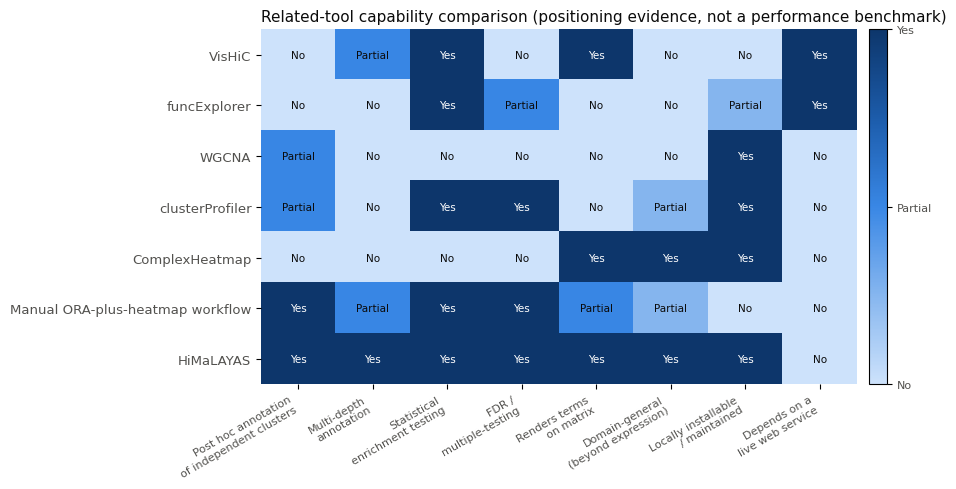

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/30_related_tool_comparison_table/tool_capability_matrix.png


In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "sequential_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

MATRIX_AXES = [
    "post_hoc_annotation_of_independent_clusters",
    "multi_depth_hierarchical_annotation",
    "statistical_enrichment_testing",
    "multiple_testing_correction_fdr",
    "renders_significant_terms_on_matrix",
    "domain_generality_beyond_expression",
    "local_installability_maintainability",
    "live_web_service_dependency",
]
AXIS_LABELS = {
    "post_hoc_annotation_of_independent_clusters": "Post hoc annotation\nof independent clusters",
    "multi_depth_hierarchical_annotation": "Multi-depth\nannotation",
    "statistical_enrichment_testing": "Statistical\nenrichment testing",
    "multiple_testing_correction_fdr": "FDR /\nmultiple-testing",
    "renders_significant_terms_on_matrix": "Renders terms\non matrix",
    "domain_generality_beyond_expression": "Domain-general\n(beyond expression)",
    "local_installability_maintainability": "Locally installable\n/ maintained",
    "live_web_service_dependency": "Depends on a\nlive web service",
}


def score_cell(value: str) -> float:
    v = value.lower()
    if v.startswith("yes"):
        return 1.0
    if v.startswith("partial") or v.startswith("likely") or v.startswith("possible"):
        return 0.5
    if v.startswith("no") or v.startswith("not documented") or v.startswith("n/a"):
        return 0.0
    return 0.25


tools = list(tool_comparison.index)
heat = pd.DataFrame(
    [[score_cell(tool_comparison.loc[t, a]) for a in MATRIX_AXES] for t in tools],
    index=tools,
    columns=MATRIX_AXES,
)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
im = ax.imshow(heat.values, cmap=SEQUENTIAL_BLUE, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(MATRIX_AXES)))
ax.set_xticklabels(
    [AXIS_LABELS[a] for a in MATRIX_AXES], fontsize=8, color=INK_SECONDARY, rotation=30, ha="right"
)
ax.set_yticks(range(len(tools)))
ax.set_yticklabels(tools, fontsize=9.5, color=INK_SECONDARY)
ax.set_title(
    "Related-tool capability comparison (positioning evidence, not a performance benchmark)",
    color=INK_PRIMARY,
    fontsize=11,
    loc="left",
)
for i, t in enumerate(tools):
    for j, a in enumerate(MATRIX_AXES):
        val = tool_comparison.loc[t, a]
        short = (
            "Yes"
            if val.lower().startswith("yes")
            else "No" if val.lower().startswith(("no", "not documented", "n/a")) else "Partial"
        )
        ax.text(
            j,
            i,
            short,
            ha="center",
            va="center",
            fontsize=7.5,
            color="white" if heat.values[i, j] > 0.55 else INK_PRIMARY,
        )
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels(["No", "Partial", "Yes"], fontsize=8, color=INK_SECONDARY)
fig.tight_layout()
capability_fig_path = NB_FIGURES_DIR / "tool_capability_matrix.png"
fig.savefig(capability_fig_path, dpi=200, bbox_inches="tight", facecolor="#fcfcfb")
plt.show()
print(f"Saved {capability_fig_path}")

## 9. GO / CONDITIONAL_GO / CONCERN decision

Decision rule (this notebook's brief), computed from the table above, not asserted:

- **GO**: no tool other than HiMaLAYAS scores `Yes` on all four axes central to the restrained claim (post hoc annotation of independent clusters, multi-depth annotation, local installability, domain generality beyond expression) -- the comparison supports the restrained novelty claim without \"first-ever\" language.
- **CONDITIONAL_GO**: HiMaLAYAS itself does not cleanly score `Yes` on all four (its own evidence is thin), forcing a narrower availability/integration-only claim.
- **CONCERN**: some other maintained tool already scores `Yes` on all four -- an existing tool already covers the same post hoc, multi-depth, installable, domain-agnostic workflow.

In [12]:
KEY_AXES = [
    "post_hoc_annotation_of_independent_clusters",
    "multi_depth_hierarchical_annotation",
    "local_installability_maintainability",
    "domain_generality_beyond_expression",
]


def is_clean_yes(value: str) -> bool:
    return value.strip().lower().startswith("yes")


key_axis_scores = {
    tool: {axis: is_clean_yes(tool_comparison.loc[tool, axis]) for axis in KEY_AXES}
    for tool in tool_comparison.index
}
for tool, scores in key_axis_scores.items():
    print(f"{tool:34s} " + "  ".join(f"{a.split('_')[0]}={s}" for a, s in scores.items()))

himalayas_all_yes = all(key_axis_scores["HiMaLAYAS"].values())
competitors_all_yes = {
    tool: all(scores.values()) for tool, scores in key_axis_scores.items() if tool != "HiMaLAYAS"
}
any_competitor_matches = any(competitors_all_yes.values())
matching_competitors = [t for t, v in competitors_all_yes.items() if v]

print(f"\nHiMaLAYAS scores clean Yes on all 4 key axes: {himalayas_all_yes}")
print(
    f"Any competing tool scores clean Yes on all 4 key axes: {any_competitor_matches} {matching_competitors}"
)

if any_competitor_matches:
    decision = "CONCERN"
elif himalayas_all_yes:
    decision = "GO"
else:
    decision = "CONDITIONAL_GO"

print(f"\nDECISION: {decision}")

VisHiC                             post=False  multi=False  local=False  domain=False
funcExplorer                       post=False  multi=False  local=False  domain=False
WGCNA                              post=False  multi=False  local=True  domain=False
clusterProfiler                    post=False  multi=False  local=True  domain=False
ComplexHeatmap                     post=False  multi=False  local=True  domain=True
Manual ORA-plus-heatmap workflow   post=True  multi=False  local=False  domain=False
HiMaLAYAS                          post=True  multi=True  local=True  domain=True

HiMaLAYAS scores clean Yes on all 4 key axes: True
Any competing tool scores clean Yes on all 4 key axes: False []

DECISION: GO


## 10. Assemble and write manifest

In [13]:
flags = []
if activation is None:
    flags.append(f"HIMALAYAS ACTIVATION FAILED: {activation_error}")
for name, r in live_status_checks.items():
    if r["live"] is None:
        flags.append(f"LIVE-SERVICE CHECK INCONCLUSIVE for {name}: {r.get('error')}")

CLAIM_BOUNDARY = (
    "This table documents each tool's stated/observed capabilities and role, and directly "
    "verifies HiMaLAYAS's own claims against its source code (Section 2) and this "
    "repository's existing multi-domain use (Section 3). It does not run any of the six "
    "comparison tools against HiMaLAYAS on a shared dataset -- that would be a performance "
    "benchmark, which is explicitly out of scope (frozen plan, Section 9, Frozen Non-Goals). "
    "It does not claim HiMaLAYAS is universally superior to any of these tools, and it does "
    "not claim no related framework or workflow exists."
)

if decision == "GO":
    next_action = (
        "Use the restrained novelty sentence in the manuscript novelty/positioning "
        "paragraph and rebuttal (see Section 9's exact wording). No competing tool covers "
        "post hoc annotation of independently defined clusters, multi-depth annotation, "
        "local installability, and domain generality simultaneously. Proceed to "
        "40_biological_utility_case_study.ipynb."
    )
elif decision == "CONDITIONAL_GO":
    next_action = (
        "Narrow the novelty claim to availability/integration only (do not claim multi-"
        "depth or domain-generality breadth beyond what Section 2/3 verified). Revisit "
        "which HiMaLAYAS capability was not cleanly verified before finalizing manuscript "
        "wording."
    )
else:
    matching = ", ".join(matching_competitors) if matching_competitors else "none"
    next_action = (
        f"PAUSE the novelty paragraph as currently scoped: {matching} already covers post "
        "hoc annotation of independent clusters, multi-depth annotation, local "
        "installability, and domain generality simultaneously. Reframe the novelty claim "
        "around a narrower differentiator before proceeding."
    )

manifest = {
    "notebook": "30_related_tool_comparison_table.ipynb",
    "status": "COMPLETE" if activation is not None else "BLOCKED",
    "decision": decision,
    "next_action": next_action,
    "generated_at_utc": ru.utc_timestamp(),
    "repo_root": str(layout["repo_root"]),
    "himalayas_source": activation if activation is not None else {"error": activation_error},
    "himalayas_capability_checks": himalayas_capability_checks,
    "domain_generality_verified_in_repo": bool(domain_generality_verified),
    "live_service_checks": live_status_checks,
    "source_code_recoverability_checks": source_status_checks,
    "sources_consulted": SOURCES_CONSULTED,
    "key_axis_scores": key_axis_scores,
    "claim_boundary": CLAIM_BOUNDARY,
    "limitations": [
        "This is a qualitative capability comparison based on documentation and, for "
        "HiMaLAYAS, direct source inspection -- it is not a computational benchmark and "
        "makes no runtime/accuracy/scalability comparison between tools.",
        "VisHiC and funcExplorer capability claims (e.g. FDR handling, multi-depth support) "
        "that are not documented in their publications/available docs are marked 'not "
        "documented' rather than guessed, and may be incomplete.",
        "Live-service and source-recoverability checks are a snapshot at the timestamps "
        "recorded in live_service_checks/source_code_recoverability_checks -- status may "
        "change if re-checked later.",
        "WGCNA/clusterProfiler/ComplexHeatmap capability claims are based on their official "
        "documentation/publications, not on installing and running the packages.",
        "This notebook does not evaluate every possible clustering+enrichment workflow or "
        "tool in the field -- only the six named in the frozen plan.",
    ],
    "novelty_sentence_to_use": NOVELTY_SENTENCE_TO_USE,
    "novelty_sentence_to_avoid": NOVELTY_SENTENCE_TO_AVOID,
    "outputs": {
        "tables": {
            "tool_comparison.csv": str(csv_path.relative_to(layout["repo_root"])),
            "tool_comparison.md": str(md_path.relative_to(layout["repo_root"])),
            "sources_consulted.csv": str(sources_path.relative_to(layout["repo_root"])),
        },
        "figures": {
            "tool_capability_matrix.png": str(capability_fig_path.relative_to(layout["repo_root"])),
        },
    },
    "flags": flags,
    "interpretation": (
        f"Decision={decision}. Across the six compared tools/workflows, no tool other than "
        "HiMaLAYAS scores a clean 'Yes' on all four axes central to the restrained novelty "
        "claim (post hoc annotation of independently defined clusters, multi-depth "
        "annotation, local installability/maintenance, domain generality beyond expression "
        f"matrices): {matching_competitors or 'none'}. HiMaLAYAS itself scores clean 'Yes' on "
        f"all four, each verified against its actual v{himalayas.__version__} source code "
        "(Section 2) or this repository's existing biological + non-biological use "
        "(Section 3), not asserted. VisHiC and funcExplorer are enrichment-guided, "
        "web-workflow-oriented historical tools, not post hoc annotators of independently "
        f"defined clusters; both hosted services were checked live and found down "
        f"({live_status_checks['VisHiC']['http_status']} and "
        f"{live_status_checks['funcExplorer']['http_status']} respectively, checked "
        f"{live_status_checks['VisHiC']['checked_at_utc']}) -- documented here as a "
        "practical reproducibility fact, not a scientific criticism. WGCNA detects modules "
        "without enrichment; clusterProfiler enriches a gene list without matrix-linked "
        "visualization or clustering; ComplexHeatmap renders without performing any "
        "statistical test; a manual ORA-plus-heatmap workflow can in principle replicate "
        "the post hoc annotation goal but is bespoke, unversioned glue code, not a "
        "maintained package. See tool_comparison.csv/tool_comparison.md for the full table "
        f"and Section 9 for the two exact novelty sentences to use/avoid."
    ),
}

manifest_path = layout["manifests_dir"] / f"{NB_ID}_manifest.json"
ru.write_manifest(manifest, manifest_path)
print(f"Manifest written to: {manifest_path}")

reloaded = json.loads(manifest_path.read_text())
assert reloaded == json.loads(json.dumps(manifest, default=str)), "manifest round-trip mismatch"
print("Manifest JSON round-trip verified.")

Manifest written to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/30_related_tool_comparison_table_manifest.json
Manifest JSON round-trip verified.


## 11. Readiness summary

In [14]:
print("=" * 72)
print(f"DECISION -- {NB_ID}")
print("=" * 72)
print(f"status:      {manifest['status']}")
print(f"decision:    {manifest['decision']}")
print(f"next_action: {manifest['next_action']}")
print()
print("Novelty sentence to USE:")
print(f"  {NOVELTY_SENTENCE_TO_USE}")
print()
print("Novelty sentence to AVOID:")
print(f'  "{NOVELTY_SENTENCE_TO_AVOID}"')
print()
print("Recommendation for manuscript/rebuttal:")
print("  Lead the novelty/positioning paragraph and the response to R1-d/R2-f/AE with the")
print("  'use' sentence above. Cite VisHiC and funcExplorer as conceptually related historical")
print("  web tools (enrichment-guided, not post hoc), noting their live services were checked")
print("  and found unavailable as of the date in Section 4/6 -- state this as a practical")
print("  reproducibility fact, not a criticism of the prior work. Cite WGCNA/clusterProfiler/")
print("  ComplexHeatmap by their specific, real gaps (module detection without enrichment;")
print("  enrichment without matrix-linked visualization or clustering; rendering without")
print("  testing) rather than a blanket 'no framework exists' claim.")
print()
print(f"Manifest:  {manifest_path}")
print(f"Tables:    {NB_TABLES_DIR}")
print(f"Figures:   {NB_FIGURES_DIR}")

DECISION -- 30_related_tool_comparison_table
status:      COMPLETE
decision:    GO
next_action: Use the restrained novelty sentence in the manuscript novelty/positioning paragraph and rebuttal (see Section 9's exact wording). No competing tool covers post hoc annotation of independently defined clusters, multi-depth annotation, local installability, and domain generality simultaneously. Proceed to 40_biological_utility_case_study.ipynb.

Novelty sentence to USE:
  Existing workflows support module detection, enrichment testing, or heatmap annotation, but they generally leave post hoc, multi-depth enrichment annotation of independently defined hierarchical matrix clusters as a manual analysis step. HiMaLAYAS packages this workflow into a maintained Python library with statistical testing, FDR control, and matrix-linked visualization.

Novelty sentence to AVOID:
  "No framework exists for post hoc enrichment-based annotation of hierarchically clustered matrices."

Recommendation for manu